In [1]:
import Pkg
Pkg.activate("/home/matteo/Projects/diffusion_inference/")

  Activating project at `~/Projects/diffusion_inference`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, PyPlot, LinearAlgebra, Statistics, JLD2

Precompiling DiffusionEvolution
  ✓ DiffusionEvolution
  1 dependency successfully precompiled in 4 seconds. 130 already precompiled.


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x, y, d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [562]:
d = 25
nsamples = 10_000
T = 1000

1000

In [563]:
M = randn(d,d) * 0.8/sqrt(d)
J = M * M'

25×25 Matrix{Float64}:
  0.559955    -0.0956385  -0.0826548  …   0.00932795   0.222847
 -0.0956385    0.411101    0.0711332      0.0780576    0.13019
 -0.0826548    0.0711332   0.511009      -0.0353384   -0.0569602
 -0.0547392   -0.106581    0.0961892     -0.0234356   -0.0707242
 -0.00932324  -0.0704491   0.161797       0.0613412   -0.0467651
 -0.105291     0.0511517  -0.0350688  …   0.026015    -0.15251
  0.11557     -0.0681532   0.0384911      0.0253673    0.184237
 -0.207908     0.0609044   0.131991       0.0620033   -0.0817733
  0.325436    -0.0673663  -0.120461       0.00972456   0.0437012
 -0.114881    -0.109219    0.0746833      0.0202996   -0.403015
  0.0519255   -0.0452718  -0.0866889  …  -0.0937802   -0.133065
  0.0744512   -0.153178    0.0793154     -0.167236    -0.140255
 -0.0377533   -0.149501   -0.0463153      0.0814444    0.0093375
 -0.0140732    0.054579   -0.0318824     -0.0465793   -0.000672142
 -0.0440505    0.1384     -0.0188367     -0.00233853   0.0721282
  0.01491

In [564]:
eigen(inv(J)).values

25-element Vector{Float64}:
    0.4832070599961946
    0.528740953195411
    0.66093186662542
    0.7074081205056809
    0.8771874892328414
    0.9617726371270532
    1.044827048502519
    1.2859179446853943
    1.439142737364443
    1.4707770086374743
    1.7837578440689266
    1.9542490639543184
    2.5566684755108713
    2.997538392763019
    3.7342857736377884
    4.528353983347281
    5.142994044953108
    5.903341495214459
    7.771745084117679
   13.695800092168959
   23.253823665241356
   31.15472392322561
  159.5453073421
  280.90695229237804
 3810.823118966872

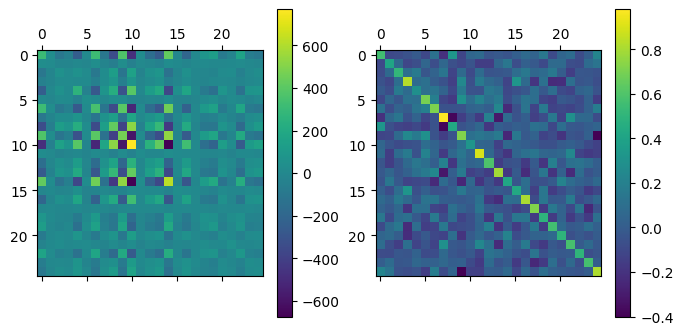

PyObject <matplotlib.colorbar.Colorbar object at 0x798d253ea350>

In [565]:
fig, ax = subplots(1,2,4)

ax[1].matshow(inv(J)) |> colorbar
ax[2].matshow(J) |> colorbar

In [566]:
θ0 = 5.0*rand(d)
θ1 = 5.0 * randn(d)
θ = θ0 .+ (θ1 .* randn(d))
θ |> norm

31.44129312790724

In [567]:
θ[[1,2]]

2-element Vector{Float64}:
 -3.0771407426534947
  2.8051711254824223

In [568]:
γ = 0.1

0.1

In [569]:
x = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T);

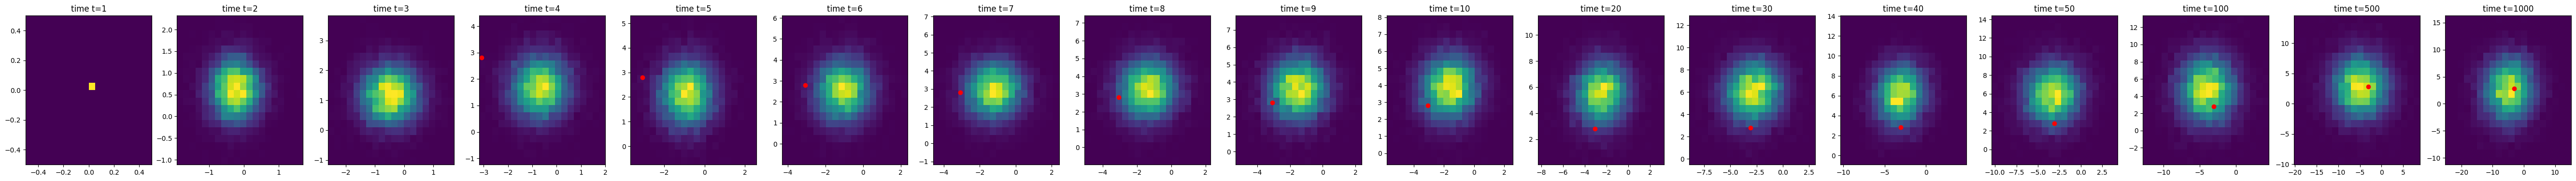

In [570]:
tpoints = [1,2,3,4,5,6,7,8,9,10,20,30,40,50,100,500,1000]
fig, ax = subplots(1, length(tpoints), 4)
for t in eachindex(tpoints)
    ax[t].hist2d(x[1,:,tpoints[t]], x[2,:,tpoints[t]], bins=20)
    ax[t].scatter(θ[1], θ[2], marker="o", color="red")
    ax[t].set_title("time t=$(tpoints[t])")
end

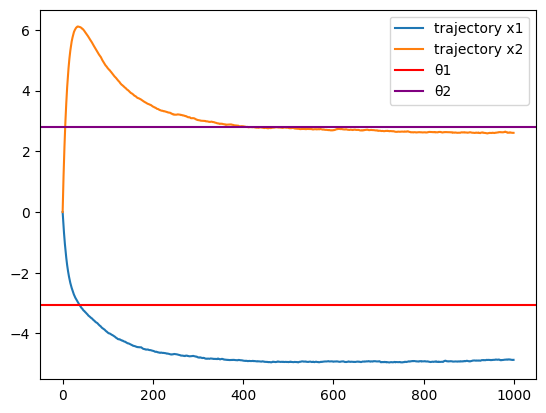

In [607]:
xt1 = vec(mean(x[1,:,:], dims=1))
xt2 = vec(mean(x[2,:,:], dims=1))
plot(xt1, label="trajectory x1")
plot(xt2, label="trajectory x2")
axhline(θ[1], color="red", label="θ1")
axhline(θ[2], color="purple", label="θ2")
legend();

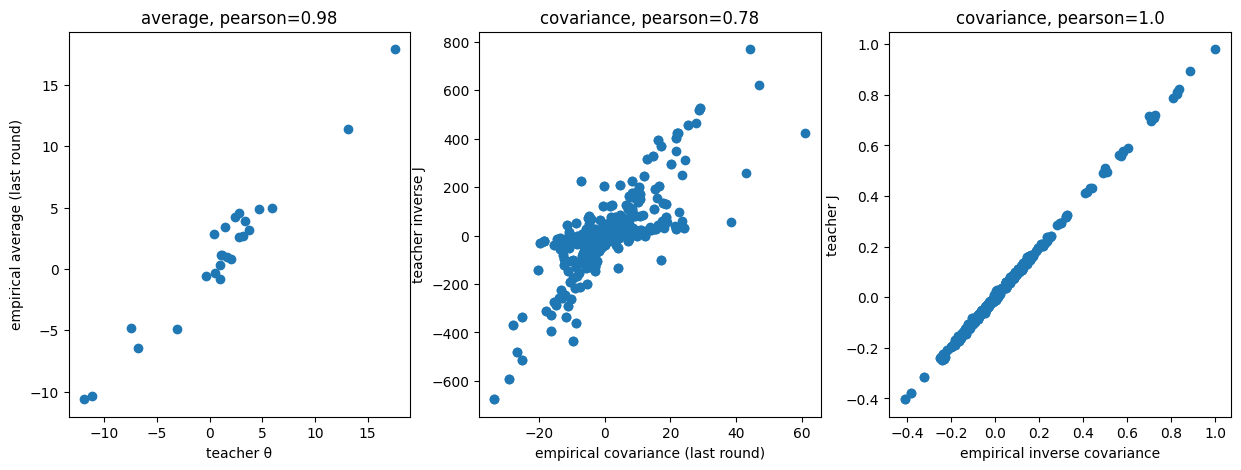

PyObject Text(0.5, 1.0, 'covariance, pearson=1.0')

In [571]:
fig, ax = subplots(1,3,5)
μ_eq = mean(x[:,:,end], dims=2)
Σ_eq = ((x[:,:,end] .- μ_eq)*(x[:,:,end] .- μ_eq)')./nsamples
#Σ_eq ./= sqrt.(diag(Σ_eq)) * sqrt.(diag(Σ_eq))'

ax[1].scatter(θ, μ_eq)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_eq))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_eq), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_eq), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_eq)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_eq)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [572]:
t_sample=[1, 2,3,4,5,10]

6-element Vector{Int64}:
  1
  2
  3
  4
  5
 10

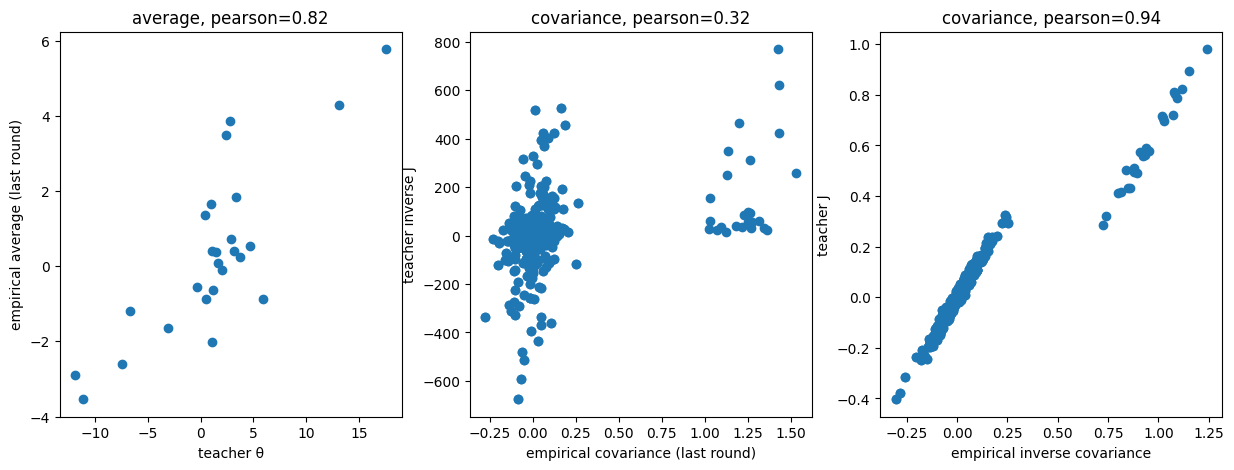

PyObject Text(0.5, 1.0, 'covariance, pearson=0.94')

In [573]:
fig, ax = subplots(1,3,5)
μ_last = mean(x[:,:,t_sample[end]], dims=2)
Σ_last = ((x[:,:,t_sample[end]] .- μ_last)*(x[:,:,t_sample[end]] .- μ_last)')./nsamples
#Σ_last ./= sqrt.(diag(Σ_last)) * sqrt.(diag(Σ_last))'

ax[1].scatter(θ, μ_last)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_last))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_last), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_last), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_last)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_last)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [574]:
counts = ones(nsamples, length(t_sample)) ./ nsamples
time = [1,2,3,4,5,10]
data = collect_data(zeros(d), x[:,:,t_sample], counts, time);

In [585]:
λ = 0.0
prior = 0.01
ftol_rel = 1e-9

1.0e-9

In [608]:
results = learn_gamma_nlopt(data, initialize=length(t_sample), λ=λ, prior=prior, ftol_rel=ftol_rel, rescale=true, epsilon=0.0)

(minf = 9.937174968954054, minx = [0.5061994909363824, -0.09056064842266726, 0.39696498290544213, -0.07677772705202021, 0.10207801053634975, 0.4567666851274003, -0.05152957154667892, -0.04859527127127853, 0.12395362174876563, 0.7638808511114299  …  2.159030004639846, 0.40332147183705275, -3.765406760109281, -4.564466560119687, 0.6582343671282948, 1.7322090412494133, -0.7091816833798811, -1.1802295603169624, 7.388334018240848, 0.0794478022125491], status = :FTOL_REACHED, nevals = 916, x_start = [1.1643248520276466, -0.07294630932112996, 1.0909239974424993, -0.0780672676490972, 0.06138768050035207, 1.1170680644154847, -0.048086692845112786, -0.10982061637638443, 0.0912644161520007, 1.199983120000182  …  1.6634895716013158, 0.25612087118918586, -2.8814507342040314, -3.5390601377599995, 0.5456824935052393, 1.3697358195056766, -0.5588711381230425, -0.8614629814433707, 5.771536538162396, 1.0])

In [609]:
results.minx[end]

0.0794478022125491

In [610]:
J_inferred = de.compute_J(results.minx, data.d);
θ_inferred = de.compute_theta(results.minx, data.d);

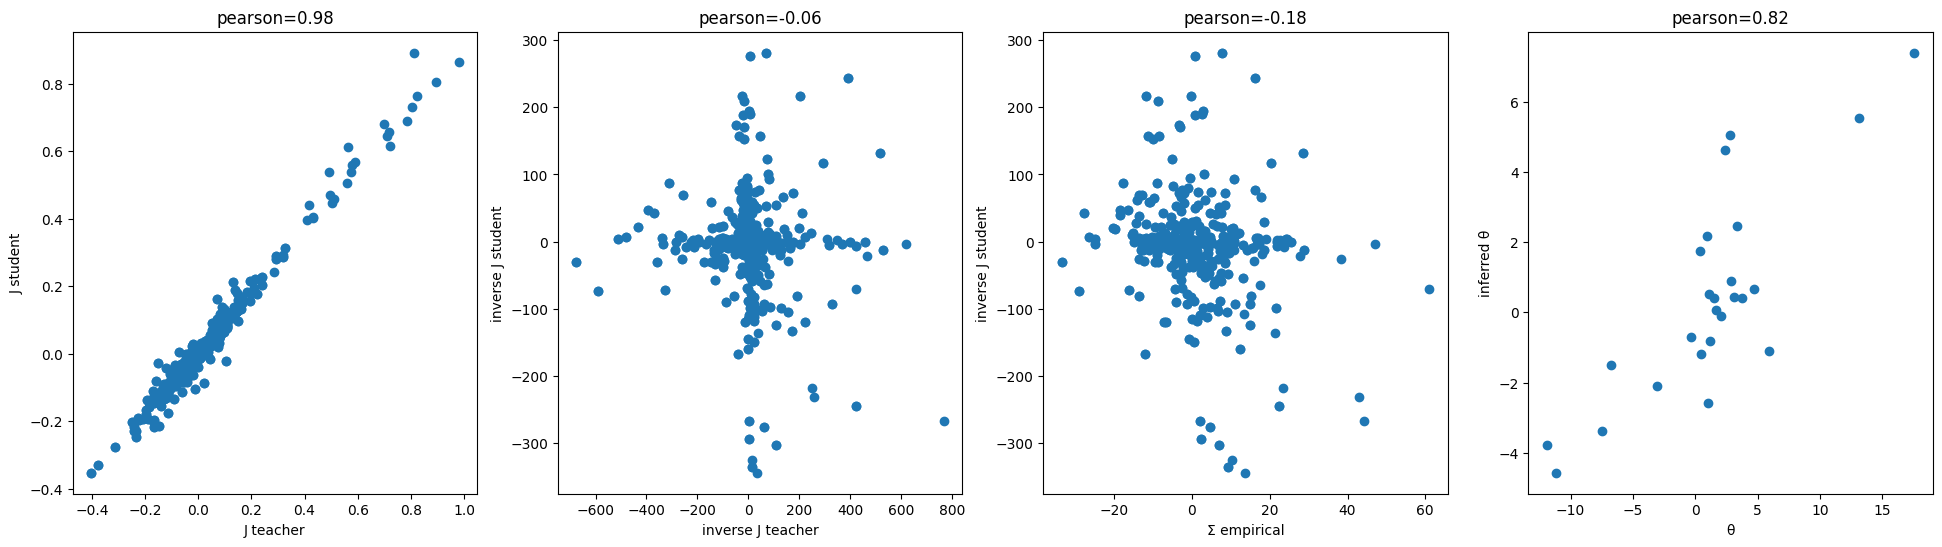

PyObject Text(0.5, 1.0, 'pearson=0.82')

In [611]:
fig, ax = subplots(1, 4, 6)
ax[1].scatter(J, J_inferred)
rho_J = cor(vec(J), vec(J_inferred))
ax[1].set_xlabel("J teacher")
ax[1].set_ylabel("J student")
ax[1].set_title("pearson=$(round(rho_J, digits=2))")

ax[2].scatter(inv(J), inv(J_inferred))
rho_invJ = cor(vec(inv(J)), vec(inv(J_inferred)))
ax[2].set_xlabel("inverse J teacher")
ax[2].set_ylabel("inverse J student")
ax[2].set_title("pearson=$(round(rho_invJ, digits=2))")

ax[3].scatter(Σ_eq, inv(J_inferred))
rho_sigma_invJ = cor(vec(Σ_eq), vec(inv(J_inferred)))
ax[3].set_xlabel("Σ empirical")
ax[3].set_ylabel("inverse J student")
ax[3].set_title("pearson=$(round(rho_sigma_invJ, digits=2))")

ax[4].scatter(θ, θ_inferred)
rho_theta = cor(vec(θ), θ_inferred)
ax[4].set_xlabel("θ")
ax[4].set_ylabel("inferred θ")
ax[4].set_title("pearson=$(round(rho_theta, digits=2))")

In [612]:
γ

0.1

In [613]:
γ_grid = collect(0.01:0.01:0.5)

50-element Vector{Float64}:
 0.01
 0.02
 0.03
 0.04
 0.05
 0.06
 0.07
 0.08
 0.09
 0.1
 0.11
 0.12
 0.13
 ⋮
 0.39
 0.4
 0.41
 0.42
 0.43
 0.44
 0.45
 0.46
 0.47
 0.48
 0.49
 0.5

In [614]:
lγ = map(x->de.log_likelihood(results.minx[1:end-1], data, x, λ, prior, 0.0), γ_grid)

50-element Vector{Float64}:
 272.53985057502354
 101.64144201913813
  50.71884544810422
  28.813181204253567
  18.125072063295594
  12.839228332703858
  10.510554236002516
   9.938847051199279
  10.469315253340687
  11.716240104797988
  13.43887094639734
  15.480078472082747
  17.733667972246362
   ⋮
  73.80545155908018
  75.33963290826212
  76.83015356610657
  78.27811226297192
  79.68460724068687
  81.05073211077044
  82.37757238907223
  83.6662025971866
  84.91768384216688
  86.13306180254703
  87.3133650615974
  88.45960373896797

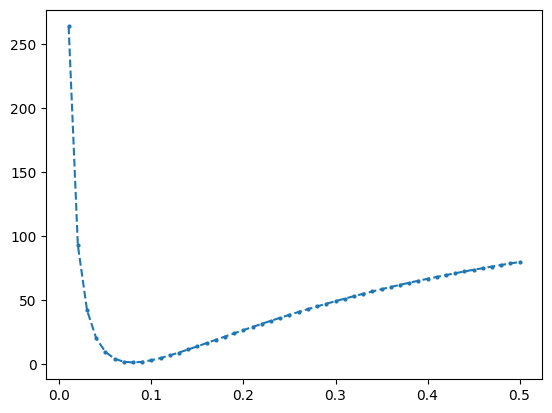

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x798d21ade680>

In [615]:
plot(γ_grid, lγ .- (minimum(lγ) - 1.0), linestyle="dashed", marker="o", markersize=2)
#xscale(:log)
#yscale(:log)

In [594]:
#@save "test1_save.jld2" d nsamples T J θ γ x results t_sample γ_grid